In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import itertools
import math
from mpl_toolkits.mplot3d import Axes3D 
from typing import Callable
from collections import Counter
from scipy.spatial import KDTree
import seaborn as sns
from sklearn.mixture import GaussianMixture
# i tried to display the data from one of the files but the output was truncated to fewer digits, this following line exists to prevent that 
np.set_printoptions(suppress=False, precision=16)

In [2]:
def process_data(filepath: str) -> tuple[np.ndarray, np.ndarray, np.ndarray]:

    """
    Args:
        filepath: string -> file that contains the data 
    
    Returns:
        X,Y where
        X: np.ndarray of size (N, dim_in) 
        Y: np.ndarray of size (N, dim_out)
        
    """
    df = pd.read_csv(filepath)

    # dynamically separate input and output columns 
    input_cols = [col for col in df.columns if col.lower().startswith("x")]
    output_cols = [col for col in df.columns if col.lower().startswith("l")]

    # convert to numpy arrays for better handlling in the future
    X = df[input_cols].to_numpy()
    Y = df[output_cols].to_numpy()

    return X,Y

# test the above code
X,Y = process_data("./Dataset1/train.csv")
for i in range(5):
    print(Y[i])


[0.]
[2.]
[1.]
[0.]
[1.]


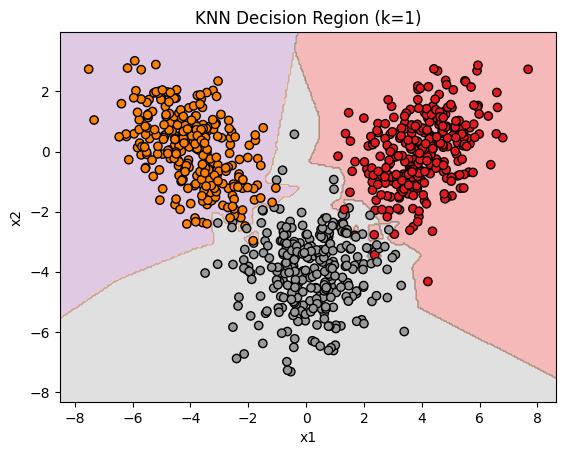

1.0

In [3]:

class KNNClassifier_fast:
    def __init__(self, n_neighbours):
        self.K = n_neighbours
        pass

    def fit(self, X, Y):
        self.X_train = np.array(X)
        self.Y_train = np.ravel(Y)
        self.tree = KDTree(self.X_train)

    def _euclidean_distance(self, x1, x2):
        return np.sqrt(np.sum((x1-x2)**2))
    
    
    def predict(self,X):
        predictions = []
        for x in X:
            distances, indices = self.tree.query(x, k = self.K)
            if self.K==1:
                indices = [indices]
            k_neighbour_labels = [self.Y_train[i] for i in indices]
            most_common = Counter(np.ravel(k_neighbour_labels)).most_common(1)[0][0]
            predictions.append(most_common)
        return predictions
    
    def accuracy(self, Y_pred, Y):
        N = len(Y_pred)
        errors = 0
        for i in range(N):
            if(Y_pred[i]!=Y[i]):
                errors+=1
        return 1- errors/N


    def plot_decision_region(self):
        #create a mesh
        xmin, xmax = self.X_train[:,0].min()-1, self.X_train[:,0].max()+1
        ymin, ymax = self.X_train[:,1].min()-1, self.X_train[:,1].max()+1
        xx, yy = np.meshgrid(
            np.arange(xmin, xmax, 0.05),
            np.arange(ymin, ymax, 0.05)
        )

        grid_points = np.c_[xx.ravel(), yy.ravel()]
        Z = self.predict(grid_points)
        Z = np.array(Z).reshape(xx.shape)

        #plot boundary
        plt.contourf(xx, yy, Z,alpha=0.3, cmap = plt.cm.Set1)


        #plot training points
        scatter = plt.scatter(self.X_train[:, 0], self.X_train[:, 1], 
                              c=self.Y_train, edgecolor='k', cmap=plt.cm.Set1)
        plt.xlabel("x1")
        plt.ylabel("x2")
        plt.title(f"KNN Decision Region (k={self.K})")
        plt.show()
        pass

    def confusion_matrix(self,Y):
        y_pred = self.predict(self.X_train)
        y_pred = np.ravel(y_pred)
        y_true = np.ravel(Y)
        
        cm = np.zeros((len(self.classes), len(self.classes)), dtype=int)
        class_to_index = {c:i for (i,c) in enumerate(self.classes)}
        # cm = {c: {d:0 for d in self.classes} for c in self.classes}
        for i in range(len(y_pred)):
            row = class_to_index[y_pred[i]]
            col = class_to_index[y_true[i]]
            cm[row][col]+=1


        row_sums = {c: len(y_true[y_true==c]) for c in self.classes}
        col_sums = {c: len(y_pred[y_pred==c]) for c in self.classes}

        precisions = []
        recalls = []
        f1_measures = []
        for c in self.classes:
            i = class_to_index[c]
            tp = cm[i, i]
            precision = tp / col_sums[c] if col_sums[c] > 0 else 0
            recall    = tp / row_sums[c] if row_sums[c] > 0 else 0
            f1        = 2*precision*recall/(precision+recall) if (precision+recall) > 0 else 0

            precisions.append(precision)
            recalls.append(recall)
            f1_measures.append(f1)

        avg_precision = np.mean(precisions)
        avg_recall    = np.mean(recalls)
        avg_f1_measure = np.mean(f1_measures)

        metrics = [precisions, recalls, f1_measures, avg_precision, avg_recall, avg_f1_measure]

        return np.array(cm), metrics
        pass

# test code
train_filepath = "./Dataset1/train.csv"
val_filepath = "./Dataset1/val.csv"
X_train, Y_train = process_data(train_filepath)
X_val, Y_val = process_data(val_filepath)
knn = KNNClassifier_fast(n_neighbours=1)
knn.fit(X_train, Y_train)
y_pred = knn.predict(X_train)
model_accuracy = knn.accuracy(y_pred, Y_train)
knn.plot_decision_region()
model_accuracy
    

In [4]:
# separate data based on class

class BayesClassifier:
    def __init__(self,same_covariance_matrices:bool ,is_it_naive:bool):
        self.same_covariance_matrices = same_covariance_matrices
        self.is_it_naive = is_it_naive
        pass

    def fit(self,X,Y):
        self.X_train = np.array(X)
        self.Y_train = np.ravel(Y)
        pass

    def log_gaussian_pdf(self, x, mu, sigma):
        d = x.shape[0]
        return -0.5*d * np.log(2*np.pi) - 0.5*np.log(np.linalg.det(sigma)) - 0.5* np.log((x-mu).T @ (np.linalg.inv(sigma)) @ (x-mu))
        pass

    def log_posterior(self,x, mu, sigma, prior):
        return np.log(prior) + self.log_gaussian_pdf(x, mu, sigma)
        pass

    def predict(self, X):

        #separate data based on class
        classes = np.unique(self.Y_train)
        class_data = {c:self.X_train[self.Y_train==c] for c in classes}

        #estimate parameters for each class
        N = len(self.X_train)
        prior = {c: len(class_data[c])/N for c in classes}
        mu = {c: np.mean(class_data[c], axis=0) for c in classes}
        sigma = {c: np.cov(class_data[c], rowvar=False) for c in classes}

        #for naive bayes classification
        if self.is_it_naive==True:
            sigma = {c:np.var(class_data[c]) for c in classes}


        #extra step for same cov matrices across all classes
        if self.same_covariance_matrices==True:
            avg_sigma = np.mean(sigma[c] for c in classes)
            sigma = {c: avg_sigma for c in classes}

        predictions = []
        for x in X:
            posteriors = {c: (self.log_posterior(x, mu[c], sigma[c], prior[c])) for c in classes}
            best_class = max(posteriors, key=posteriors.get)
            predictions.append(best_class)
        
        return predictions
    
    def accuracy(self, Y_pred, Y):
        N = len(Y_pred)
        errors = 0
        for i in range(N):
            if(Y_pred[i]!=Y[i]):
                errors+=1
        return 1- errors/N
    
    def confusion_matrix(self,Y):
        y_pred = self.predict(self.X_train)
        y_pred = np.ravel(y_pred)
        y_true = np.ravel(Y)
        
        cm = np.zeros((len(self.classes), len(self.classes)), dtype=int)
        class_to_index = {c:i for (i,c) in enumerate(self.classes)}
        # cm = {c: {d:0 for d in self.classes} for c in self.classes}
        for i in range(len(y_pred)):
            row = class_to_index[y_pred[i]]
            col = class_to_index[y_true[i]]
            cm[row][col]+=1


        row_sums = {c: len(y_true[y_true==c]) for c in self.classes}
        col_sums = {c: len(y_pred[y_pred==c]) for c in self.classes}

        precisions = []
        recalls = []
        f1_measures = []
        for c in self.classes:
            i = class_to_index[c]
            tp = cm[i, i]
            precision = tp / col_sums[c] if col_sums[c] > 0 else 0
            recall    = tp / row_sums[c] if row_sums[c] > 0 else 0
            f1        = 2*precision*recall/(precision+recall) if (precision+recall) > 0 else 0

            precisions.append(precision)
            recalls.append(recall)
            f1_measures.append(f1)

        avg_precision = np.mean(precisions)
        avg_recall    = np.mean(recalls)
        avg_f1_measure = np.mean(f1_measures)

        metrics = [precisions, recalls, f1_measures, avg_precision, avg_recall, avg_f1_measure]

        return np.array(cm), metrics
        pass
    



# test code
train_filepath = "./Dataset1/train.csv"
val_filepath = "./Dataset1/val.csv"
X_train, Y_train = process_data(train_filepath)
X_val, Y_val = process_data(val_filepath)
bc = BayesClassifier(same_covariance_matrices=False, is_it_naive=False)
bc.fit(X_train, Y_train)
y_pred = bc.predict(X_train)
model_accuracy = bc.accuracy(y_pred, Y_train)
model_accuracy

0.9738095238095238

In [6]:
#gmm based classifier

from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms

class GMMClassifier:
    
    def __init__(self, n_components: int, is_covariance_matrix_diagonal: bool):
        self.n_components = n_components
        self.is_covariance_matrix_diagonal = is_covariance_matrix_diagonal
        self.priors = {}
        self.models = {}
        pass

    def fit(self, X, Y):
        self.X_train = np.array(X)
        self.Y_train = np.ravel(Y)
        self.classes = np.unique(self.Y_train)
        for c in self.classes:
            c = int(c)
        for c in self.classes:
            X_c = self.X_train[self.Y_train==c]
            self.priors[c] = len(X_c)/len(self.X_train)
            gmm = GaussianMixture(n_components=self.n_components, covariance_type="full")

            #for diag cov matrix do this
            if self.is_covariance_matrix_diagonal==True:
                gmm = GaussianMixture(n_components=self.n_components, covariance_type="diag")
            
            gmm.fit(X_c)
            self.models[c] = gmm

        pass

    def log_posterior(self,x,c):
        return np.log(self.priors[c]) + self.models[c].score_samples([x])[0]
        pass

    def predict(self, X):
        predictions = []

        for x in X:
            posteriors = {c: self.log_posterior(x, c) for c in self.classes}
            best_class = max(posteriors, key=posteriors.get)
            predictions.append(best_class)
        
        return np.array(predictions)
        pass

    def accuracy(self, Y_pred, Y):
        N = len(Y_pred)
        errors = 0
        for i in range(N):
            if(Y_pred[i]!=Y[i]):
                errors+=1
        return 1- errors/N
    
    def confusion_matrix(self,Y):
        y_pred = self.predict(self.X_train)
        y_pred = np.ravel(y_pred)
        y_true = np.ravel(Y)
        
        cm = np.zeros((len(self.classes), len(self.classes)), dtype=int)
        class_to_index = {c:i for (i,c) in enumerate(self.classes)}
        # cm = {c: {d:0 for d in self.classes} for c in self.classes}
        for i in range(len(y_pred)):
            row = class_to_index[y_pred[i]]
            col = class_to_index[y_true[i]]
            cm[row][col]+=1


        row_sums = {c: len(y_true[y_true==c]) for c in self.classes}
        col_sums = {c: len(y_pred[y_pred==c]) for c in self.classes}

        precisions = []
        recalls = []
        f1_measures = []
        for c in self.classes:
            i = class_to_index[c]
            tp = cm[i, i]
            precision = tp / col_sums[c] if col_sums[c] > 0 else 0
            recall    = tp / row_sums[c] if row_sums[c] > 0 else 0
            f1        = 2*precision*recall/(precision+recall) if (precision+recall) > 0 else 0

            precisions.append(precision)
            recalls.append(recall)
            f1_measures.append(f1)

        avg_precision = np.mean(precisions)
        avg_recall    = np.mean(recalls)
        avg_f1_measure = np.mean(f1_measures)

        metrics = [precisions, recalls, f1_measures, avg_precision, avg_recall, avg_f1_measure]

        return np.array(cm), metrics
        pass
    
    def plot_decision_regions(self, resolution=200, alpha=0.3):
        if self.X_train.shape[1] != 2:
            raise ValueError("plot_decision_regions works only for 2D data.")

        x_min, x_max = self.X_train[:, 0].min() - 1, self.X_train[:, 0].max() + 1
        y_min, y_max = self.X_train[:, 1].min() - 1, self.X_train[:, 1].max() + 1

        xx, yy = np.meshgrid(
            np.linspace(x_min, x_max, resolution),
            np.linspace(y_min, y_max, resolution)
        )
        grid = np.c_[xx.ravel(), yy.ravel()]

        # predict class for each grid point
        Z = self.predict(grid)
        Z = Z.reshape(xx.shape)

        plt.figure(figsize=(8, 6))

        # plot decision regions
        plt.contourf(xx, yy, Z, alpha=alpha, cmap=plt.cm.Set2)

        # plot training data
        for c in self.classes:
            X_c = self.X_train[self.Y_train == c]
            plt.scatter(X_c[:, 0], X_c[:, 1], label=f"Class {c}", edgecolor="k")

        plt.title("GMM Classifier - Decision Regions")
        plt.xlabel("Feature 1")
        plt.ylabel("Feature 2")
        plt.legend()
        plt.show()

    
    def plot_level_curves(self, resolution=2000):

        if self.X_train.shape[1] != 2:
            raise ValueError("plot_level_curves works only for 2D data.")

        x_min, x_max = self.X_train[:, 0].min() - 1, self.X_train[:, 0].max() + 1
        y_min, y_max = self.X_train[:, 1].min() - 1, self.X_train[:, 1].max() + 1
        
        xx, yy = np.meshgrid(
            np.linspace(x_min, x_max, resolution),
            np.linspace(y_min, y_max, resolution)
        )
        grid = np.c_[xx.ravel(), yy.ravel()]

        plt.figure(figsize=(8, 6))

        # plot training points
        for c in self.classes:
            X_c = self.X_train[self.Y_train == c]
            plt.scatter(X_c[:, 0], X_c[:, 1], label=f"Class {c}", s=25)

        
        def plot_cov_ellipse(mean, cov, n_std=2.0, **kwargs):
            """Plot an ellipse representing the covariance matrix."""
            pearson = cov[0, 1] / np.sqrt(cov[0, 0] * cov[1, 1])
            ell_radius_x = np.sqrt(1 + pearson)
            ell_radius_y = np.sqrt(1 - pearson)

            ellipse = Ellipse((0, 0),
                            width=ell_radius_x * 2,
                            height=ell_radius_y * 2,
                            **kwargs)

            # scale to the right size
            scale_x = np.sqrt(cov[0, 0]) * n_std
            scale_y = np.sqrt(cov[1, 1]) * n_std
            transf = transforms.Affine2D() \
                .rotate_deg(45) \
                .scale(scale_x, scale_y) \
                .translate(mean[0], mean[1])

            ellipse.set_transform(transf + plt.gca().transData)
            plt.gca().add_patch(ellipse)

        # plot GMM level curves
        for c in self.classes:
            gmm = self.models[c]
            for mean, covar in zip(gmm.means_, gmm.covariances_):
                if self.is_covariance_matrix_diagonal:
                    covar = np.diag(covar)  # convert diag to full

                plot_cov_ellipse(mean, covar, n_std=2, alpha=0.3)

        plt.title("GMM Classifier - Level Curves")
        plt.xlabel("Feature 1")
        plt.ylabel("Feature 2")
        plt.legend()
        plt.show()
    
# test code
train_filepath = "./Dataset1/train.csv"
val_filepath = "./Dataset1/val.csv"
X_train, Y_train = process_data(train_filepath)
X_val, Y_val = process_data(val_filepath)
gc = GMMClassifier(n_components=1, is_covariance_matrix_diagonal = True)
gc.fit(X_train, Y_train)
y_pred = gc.predict(X_train)
model_accuracy = gc.accuracy(y_pred, Y_train)
# gc.plot_level_curves()
# gc.plot_decision_regions()
confusion_matrix,metrics = gc.confusion_matrix(Y_train)
print(confusion_matrix)
for item in metrics:
    print(item)
# model_accuracy



[[278   0   1]
 [  0 266   4]
 [  7   6 278]]
[np.float64(0.996415770609319), np.float64(0.9851851851851852), np.float64(0.9553264604810997)]
[np.float64(0.9754385964912281), np.float64(0.9779411764705882), np.float64(0.9823321554770318)]
[np.float64(0.9858156028368794), np.float64(0.981549815498155), np.float64(0.9686411149825784)]
0.9789758054252014
0.9785706428129494
0.9786688444392043
